# CMIP6 Multi-Model Rainfall Analysis (Updated Data)

This notebook rewrites the original rainfall exceedance analysis to use the newer dataset in `data/CMIP6_Annual_Exceedance_Change-2`. It computes multi-model ensemble statistics for annual exceedance change and exports the processed results.

## Import Required Libraries

Load the libraries needed for data handling, raster reading, analysis, and plotting. Cartopy is optional and only used if available.

In [24]:
import os
import re
import glob
import numpy as np
import pandas as pd

import xarray as xr
import rasterio
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    CARTOPY_AVAILABLE = True
except ImportError:
    CARTOPY_AVAILABLE = False

try:
    from scipy.stats import ttest_1samp
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 11})

## Load Data from New Folder

Identify TIFF files in the updated data folder and load them into xarray-friendly objects. The new folder contains annual exceedance change results for each model.

In [25]:
base_dir = 'data/CMIP6_Annual_Exceedance_Change-2'
search_pattern = os.path.join(base_dir, '*_AnnualExceedanceChange.tif')
files = sorted(glob.glob(search_pattern))

if not files:
    raise FileNotFoundError(f'No files found in {base_dir} with pattern {search_pattern}')

print(f'Found {len(files)} model files in the new dataset.')

thresholds = ['t10', 't25', 't50', 't100']

import collections
scenario_data = collections.defaultdict(dict)

filename_pattern = re.compile(r'(?P<model>.+?)_ssp(?P<scenario>\d{3})_AnnualExceedanceChange\.tif$')

def parse_filename(path):
    name = os.path.basename(path)
    match = filename_pattern.match(name)
    if not match:
        raise ValueError(f'Unexpected filename format: {name}')
    return match.group('model'), f"ssp{match.group('scenario')}"


def load_model_raster(path):
    with rasterio.open(path) as src:
        data = src.read().astype('float32')
        if data.shape[0] != len(thresholds):
            raise ValueError(f'Expected {len(thresholds)} bands in {path}, got {data.shape[0]}')
        transform = src.transform
        x = transform.c + np.arange(src.width) * transform.a + transform.a / 2
        y = transform.f + np.arange(src.height) * transform.e + transform.e / 2
        model_name, scenario = parse_filename(path)
        da = xr.DataArray(
            data,
            dims=('threshold', 'y', 'x'),
            coords={'threshold': thresholds, 'y': y, 'x': x},
            attrs={'model_name': model_name, 'scenario': scenario, 'crs': str(src.crs)}
        )
        return model_name, scenario, da

for path in files:
    model_name, scenario, da = load_model_raster(path)
    scenario_data[scenario][model_name] = da

print('Loaded raster data for scenarios:')
for scenario, models in scenario_data.items():
    print(f'  {scenario}: {len(models)} models')


Found 32 model files in the new dataset.
Loaded raster data for scenarios:
  ssp585: 32 models


## Data Preprocessing and Cleaning

Clean the loaded data by masking NoData values and aligning all raster grids to a common geometry. This ensures the multi-model aggregation is consistent.

In [26]:
# Determine reference geometry from the first DataArray
template = next(iter(model_data.values()))
ref_thresholds = template['threshold'].values
ref_y = template['y'].values
ref_x = template['x'].values

for model_name, da in model_data.items():
    if da.shape != template.shape:
        raise ValueError(f'Mismatch in raster dimensions for model {model_name}: {da.shape} != {template.shape}')
    if not np.array_equal(da['threshold'].values, ref_thresholds):
        raise ValueError(f'Threshold coordinate mismatch for model {model_name}')
    if not np.allclose(da['x'].values, ref_x) or not np.allclose(da['y'].values, ref_y):
        raise ValueError(f'Raster coordinate mismatch for model {model_name}')

# Replace extreme nodata and invalid values with NaN
cleaned_data = {}
for model_name, da in model_data.items():
    cleaned_data[model_name] = da.where(np.isfinite(da), np.nan)

print('Finished preprocessing and cleaning data.')

Finished preprocessing and cleaning data.


## Calculate Annual Exceedance Changes

The dataset already contains annual exceedance change values, so this step verifies the loaded values and computes per-model summary statistics.

In [27]:
summary_records = []
for scenario, models in scenario_data.items():
    for model_name, da in models.items():
        for threshold in da['threshold'].values:
            band = da.sel(threshold=threshold)
            summary_records.append({
                'scenario': scenario,
                'model': model_name,
                'threshold': str(threshold),
                'mean_change': float(np.nanmean(band.values)),
                'median_change': float(np.nanmedian(band.values)),
                'std_change': float(np.nanstd(band.values)),
                'min_change': float(np.nanmin(band.values)),
                'max_change': float(np.nanmax(band.values))
            })

model_summary = pd.DataFrame(summary_records)
model_summary = model_summary.sort_values(['scenario', 'threshold', 'mean_change'], ascending=[True, True, False]).reset_index(drop=True)
model_summary.head(20)

scenario_threshold_summary = (
    model_summary
    .groupby(['scenario', 'threshold'])
    .agg(model_count=('model', 'size'),
         mean_change=('mean_change', 'mean'),
         median_change=('median_change', 'mean'),
         std_change=('std_change', 'mean'))
    .reset_index()
)

scenario_threshold_summary

,scenario,threshold,model_count,mean_change,median_change,std_change
0,ssp585,t10,32,0.101072,0.0,0.140735
1,ssp585,t100,32,0.004843,0.0,0.019742
2,ssp585,t25,32,0.042561,0.0,0.071796
3,ssp585,t50,32,0.015352,0.0,0.036378


## Multi-Model Aggregation

Compute ensemble statistics across all models, including mean, median, and standard deviation of annual exceedance change.

In [28]:
scenario_list = sorted(scenario_data.keys())
stack_shape = (len(scenario_list), len(thresholds), len(ref_y), len(ref_x))

ensemble_mean_stack = np.full(stack_shape, np.nan, dtype='float32')
ensemble_median_stack = np.full(stack_shape, np.nan, dtype='float32')
ensemble_std_stack = np.full(stack_shape, np.nan, dtype='float32')

for si, scenario in enumerate(scenario_list):
    models = scenario_data[scenario]
    stack = np.stack([models[m].values for m in sorted(models)], axis=0)
    ensemble_mean_stack[si] = np.nanmean(stack, axis=0)
    ensemble_median_stack[si] = np.nanmedian(stack, axis=0)
    ensemble_std_stack[si] = np.nanstd(stack, axis=0)

ensemble_da = xr.Dataset({
    'ensemble_mean': (('scenario', 'threshold', 'y', 'x'), ensemble_mean_stack),
    'ensemble_median': (('scenario', 'threshold', 'y', 'x'), ensemble_median_stack),
    'ensemble_std': (('scenario', 'threshold', 'y', 'x'), ensemble_std_stack)
}, coords={'scenario': scenario_list, 'threshold': thresholds, 'y': ref_y, 'x': ref_x})

ensemble_stats = []
for scenario in scenario_list:
    for ti, threshold in enumerate(thresholds):
        data = ensemble_da['ensemble_mean'].sel(scenario=scenario, threshold=threshold)
        ensemble_stats.append({
            'scenario': scenario,
            'threshold': threshold,
            'global_mean': float(np.nanmean(data.values)),
            'global_median': float(np.nanmedian(data.values)),
            'global_std': float(np.nanstd(data.values))
        })

ensemble_stats = pd.DataFrame(ensemble_stats)
ensemble_stats

/var/folders/vw/_7ms67xn1jxb_9zqbfcn4q080000gn/T/ipykernel_25344/1324480922.py:11: RuntimeWarning: Mean of empty slice
  ensemble_mean_stack[si] = np.nanmean(stack, axis=0)
/var/folders/vw/_7ms67xn1jxb_9zqbfcn4q080000gn/T/ipykernel_25344/1324480922.py:12: RuntimeWarning: All-NaN slice encountered
  ensemble_median_stack[si] = np.nanmedian(stack, axis=0)
/Users/mehdihatamigoloujeh/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,scenario,threshold,global_mean,global_median,global_std
0,ssp585,t10,0.101072,0.0,0.113219
1,ssp585,t25,0.042561,0.0,0.050641
2,ssp585,t50,0.015352,0.0,0.022581
3,ssp585,t100,0.004843,0.0,0.012784


## Statistical Analysis

Perform statistical evaluation of the ensemble changes, including a one-sample test against zero if SciPy is installed.

In [29]:
baseline_returns = np.array([10.0, 25.0, 50.0, 100.0])
baseline_freq = 1.0 / baseline_returns

equivalent_rows = []
for _, row in ensemble_stats.iterrows():
    threshold_index = thresholds.index(row['threshold'])
    future_freq = baseline_freq[threshold_index] + row['global_mean']
    if future_freq > 0:
        equivalent_return = float(1.0 / future_freq)
    else:
        equivalent_return = np.nan
    equivalent_rows.append({
        'scenario': row['scenario'],
        'threshold': row['threshold'],
        'global_mean_change': row['global_mean'],
        'global_median_change': row['global_median'],
        'global_std': row['global_std'],
        'baseline_return_years': baseline_returns[threshold_index],
        'equivalent_return_years': equivalent_return
    })

threshold_change_table = pd.DataFrame(equivalent_rows)
threshold_change_table = threshold_change_table[['scenario', 'threshold', 'baseline_return_years', 'global_mean_change', 'equivalent_return_years', 'global_std']]
threshold_change_table


,scenario,threshold,baseline_return_years,global_mean_change,equivalent_return_years,global_std
0,ssp585,t10,10.0,0.101072,4.973348,0.113219
1,ssp585,t25,25.0,0.042561,12.112256,0.050641
2,ssp585,t50,50.0,0.015352,28.286560,0.022581
3,ssp585,t100,100.0,0.004843,67.372709,0.012784


## Visualization of Results

Plot the ensemble mean map, standard deviation map, and the distribution of model mean changes. If Cartopy is available, a geographic map will be used.

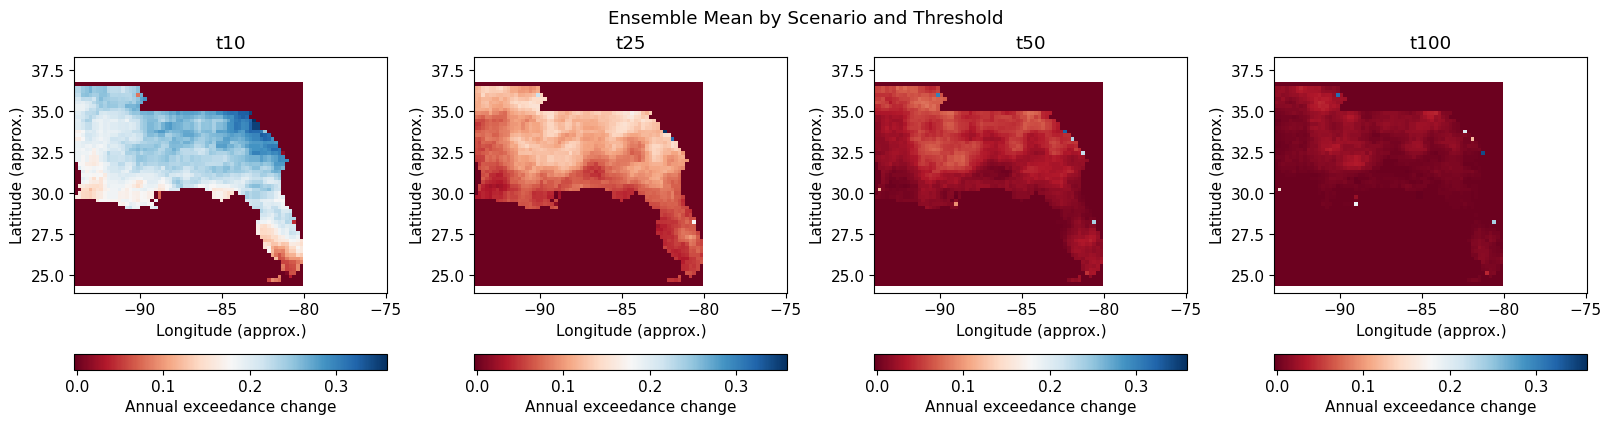

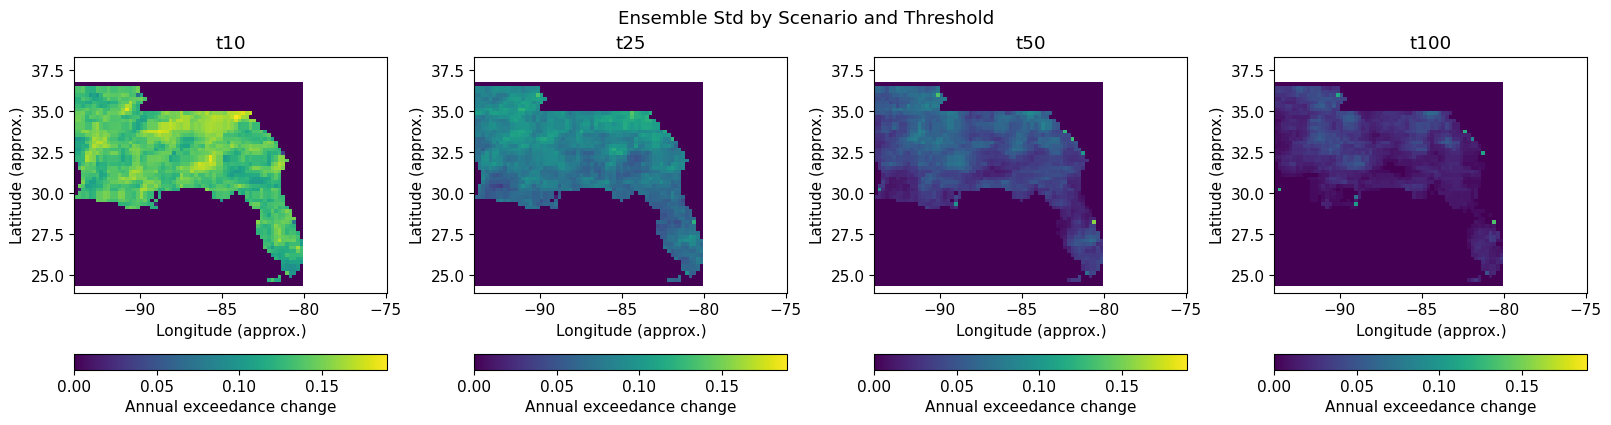

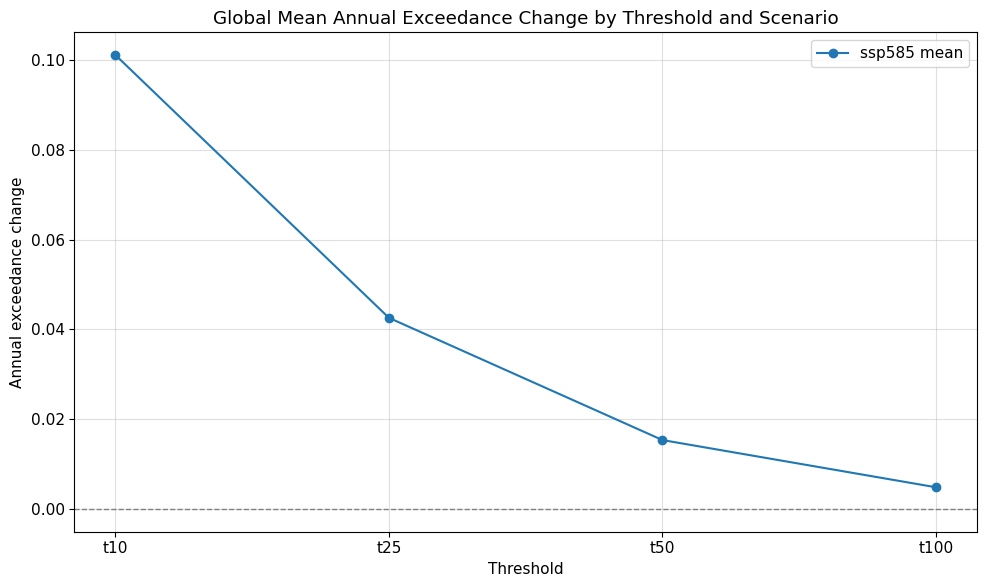

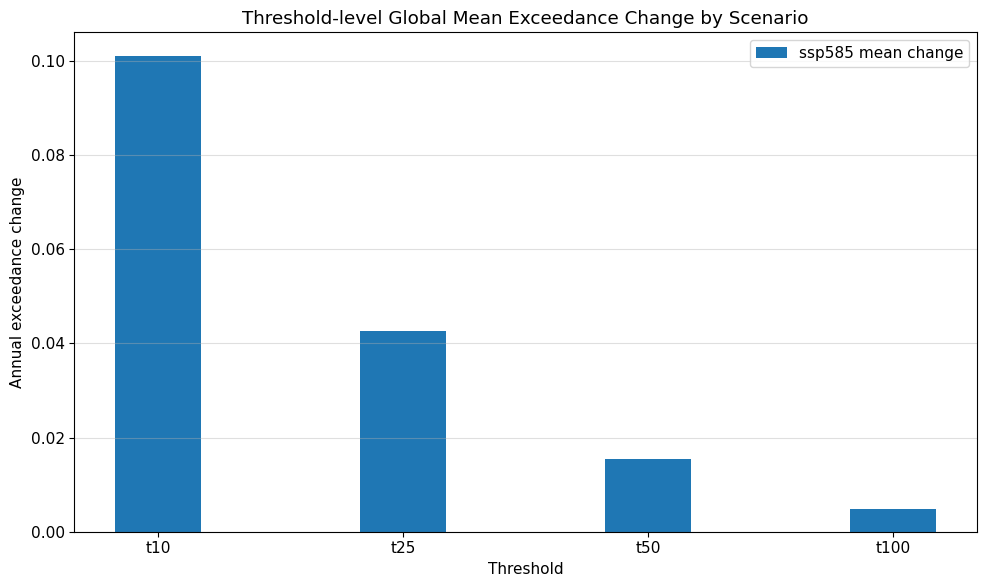

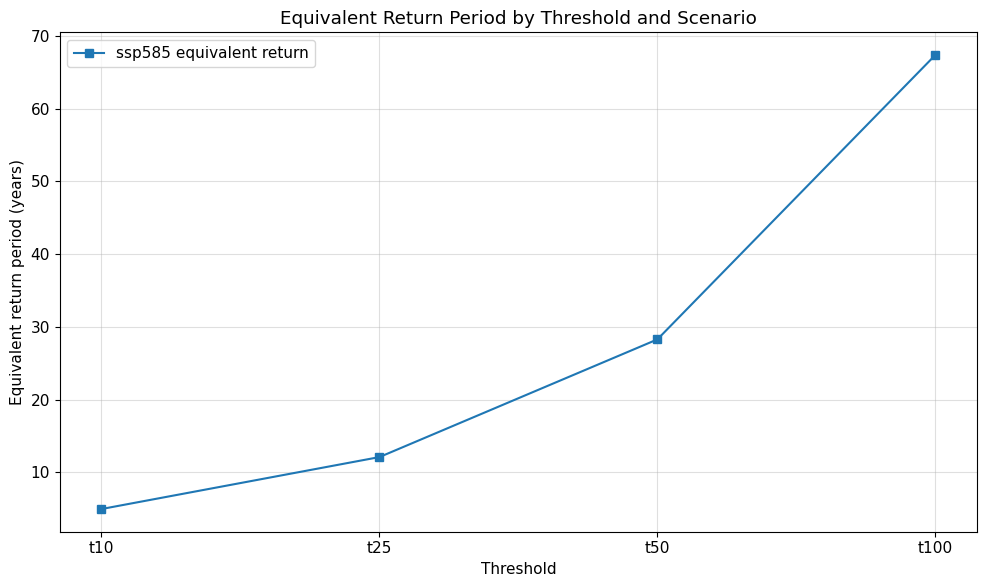

In [30]:
def plot_scenario_threshold_maps(dataset, var, title_prefix, cmap='RdBu'):
    rows = len(scenario_list)
    cols = len(thresholds)
    vmin = float(np.nanmin(dataset[var].values))
    vmax = float(np.nanmax(dataset[var].values))

    if CARTOPY_AVAILABLE:
        fig = plt.figure(figsize=(4 * cols, 4 * rows))
        for ri, scenario in enumerate(scenario_list):
            for ci, threshold in enumerate(thresholds):
                data = dataset[var].sel(scenario=scenario, threshold=threshold)
                ax = fig.add_subplot(rows, cols, ri * cols + ci + 1, projection=ccrs.PlateCarree())
                mesh = ax.pcolormesh(data['x'], data['y'], data.values, cmap=cmap, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
                ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
                ax.add_feature(cfeature.BORDERS, linewidth=0.3)
                if ri == 0:
                    ax.set_title(threshold)
                if ci == 0:
                    ax.set_ylabel(scenario)
                fig.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.05, label='Annual exceedance change')
        fig.suptitle(f'{title_prefix} by Scenario and Threshold', y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), constrained_layout=True)
        for ri, scenario in enumerate(scenario_list):
            for ci, threshold in enumerate(thresholds):
                ax = axes[ri][ci] if rows > 1 else axes[ci]
                data = dataset[var].sel(scenario=scenario, threshold=threshold)
                im = ax.imshow(data.values, origin='upper', cmap=cmap, vmin=vmin, vmax=vmax,
                               extent=[data['x'].min(), data['x'].max(), data['y'].min(), data['y'].max()])
                if ri == 0:
                    ax.set_title(threshold)
                if ci == 0:
                    ax.set_ylabel(scenario)
                ax.set_xlabel('Longitude (approx.)')
                ax.set_ylabel('Latitude (approx.)')
                fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, label='Annual exceedance change')
        fig.suptitle(f'{title_prefix} by Scenario and Threshold', y=1.02)
        plt.show()

plot_scenario_threshold_maps(ensemble_da, 'ensemble_mean', 'Ensemble Mean')
plot_scenario_threshold_maps(ensemble_da, 'ensemble_std', 'Ensemble Std', cmap='viridis')

# Summary line plots for scenario threshold changes
plt.figure(figsize=(10, 6))
for scenario in sorted(threshold_change_table['scenario'].unique()):
    subset = threshold_change_table[threshold_change_table['scenario'] == scenario]
    plt.plot(subset['threshold'], subset['global_mean_change'], marker='o', label=f'{scenario} mean')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Global Mean Annual Exceedance Change by Threshold and Scenario')
plt.xlabel('Threshold')
plt.ylabel('Annual exceedance change')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
width = 0.35
x = np.arange(len(thresholds))
for i, scenario in enumerate(sorted(threshold_change_table['scenario'].unique())):
    subset = threshold_change_table[threshold_change_table['scenario'] == scenario]
    plt.bar(x + i * width, subset['global_mean_change'].values, width, label=f'{scenario} mean change')
plt.xticks(x + width * (len(scenario_list) - 1) / 2, thresholds)
plt.title('Threshold-level Global Mean Exceedance Change by Scenario')
plt.xlabel('Threshold')
plt.ylabel('Annual exceedance change')
plt.legend()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for scenario in sorted(threshold_change_table['scenario'].unique()):
    subset = threshold_change_table[threshold_change_table['scenario'] == scenario]
    plt.plot(subset['threshold'], subset['equivalent_return_years'], marker='s', label=f'{scenario} equivalent return')
plt.title('Equivalent Return Period by Threshold and Scenario')
plt.xlabel('Threshold')
plt.ylabel('Equivalent return period (years)')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Export Processed Data

Save the ensemble results and the model summary statistics to the updated folder. This keeps the new analysis outputs alongside the new dataset.

In [31]:
output_dir = os.path.join(base_dir, 'processed_outputs')
os.makedirs(output_dir, exist_ok=True)

# Save model summary table and threshold-level stats
summary_csv = os.path.join(output_dir, 'model_summary_statistics_by_threshold.csv')
model_summary.to_csv(summary_csv, index=False)

threshold_stats_csv = os.path.join(output_dir, 'threshold_change_table.csv')
threshold_change_table.to_csv(threshold_stats_csv, index=False)

reference_path = files[0]
with rasterio.open(reference_path) as ref_src:
    out_meta = ref_src.meta.copy()
    out_meta.update(dtype='float32', count=len(thresholds))

for scenario in scenario_list:
    scenario_meta = out_meta.copy()
    scenario_meta.update(count=len(thresholds))
    out_path = os.path.join(output_dir, f'ensemble_mean_{scenario}_AnnualExceedanceChange.tif')
    with rasterio.open(out_path, 'w', **scenario_meta) as dst:
        dst.write(ensemble_da['ensemble_mean'].sel(scenario=scenario).astype('float32').values)

print(f'Saved model summary to: {summary_csv}')
print(f'Saved threshold change table to: {threshold_stats_csv}')
print(f'Saved scenario ensemble rasters to: {output_dir}')
print('Completed exports for the updated dataset.')

Saved model summary to: data/CMIP6_Annual_Exceedance_Change-2/processed_outputs/model_summary_statistics_by_threshold.csv
Saved threshold change table to: data/CMIP6_Annual_Exceedance_Change-2/processed_outputs/threshold_change_table.csv
Saved scenario ensemble rasters to: data/CMIP6_Annual_Exceedance_Change-2/processed_outputs
Completed exports for the updated dataset.
